In [1]:
import torch
print(torch.__version__)



2.5.0+cu121


In [2]:
'''
 MNIST包含70,000张手写数字图像: 60,000张用于训练，10,000张用于测试。
 图像是灰度的，28x28像素的，并且居中的，以减少预处理和加快运行。
'''
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [3]:
'''下载训练数据集（包含训练图片+标签）'''
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),#张量
)   #对于pytorch库能够识别的数据一般是tensor张量 tensorflow
# datasets.MNIST的参数：
#   root(string)： 表示数据集的根目录，
#   train(bool, optional)： 如果为True，则从training.pt创建数据集，否则从test.pt创建数据集
#   download(bool, optional)： 如果为True，则从internet下载数据集并将其放入根目录。如果数据集已下载，则不会再次下载
#   transform(callable, optional)： 接收PIL图片并返回转换后版本图片的转换函数

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 36.3MB/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 8.17MB/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.20MB/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [4]:
'''下载测试数据集（包含训练图片+标签） '''
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)
print(len(training_data))

60000


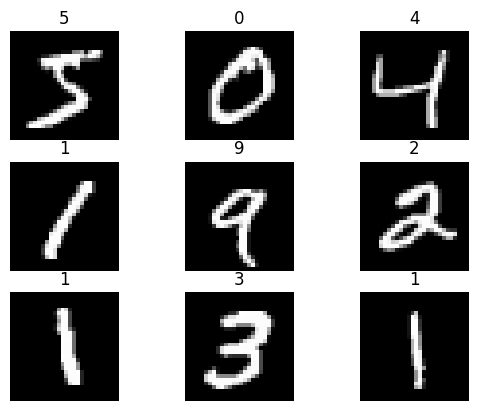

In [5]:
'''展示手写字图片，把训练数据集中的前9张图片展示一下'''
from matplotlib import pyplot as plt
figure = plt.figure()
for i in range(9):
    img, label = training_data[i]#0
    figure.add_subplot(3, 3, i+1)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


In [ ]:
# '''创建数据DataLoader（数据加载器）
#     batch_size:将数据集分成多份，每一份为batch_size个数据。
#            优点：可以减少内存的使用，提高训练速度。
# '''
train_dataloader = DataLoader(training_data, batch_size=64)#64张图片为一个包，
test_dataloader = DataLoader(test_data, batch_size=64)
for X, y in test_dataloader:#X是表示打包好的每一个数据包
    print(f"Shape of X [N, C, H, W]: {X.shape}")#
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

In [7]:
'''判断当前设备是否支持GPU，其中mps是苹果m系列芯片的GPU。'''
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [ ]:
''' 定义神经网络  '''
class NeuralNetwork(nn.Module):#
    def __init__(self):#python基础关于类
        super().__init__()
        self.flatten = nn.Flatten()#展开成为线性神经元28*28=784个
        self.hidden1 = nn.Linear(28*28, 128)#隐涵层相应也是28*28个神经元，结果变为128个输出
        self.hidden2 = nn.Linear(128, 256)
        self.out = nn.Linear(256, 10)
    def forward(self, x):   #是神经层连接起来，x
        x = self.flatten(x) #self.flatten = nn.Flatten()#展开成为线性神经元28*28=784个
        x = self.hidden1(x) # self.hidden1 = nn.Linear(28*28, 128)
        x = torch.sigmoid(x) #非线性激活层1
        x = self.hidden2(x) #self.hidden2 = nn.Linear(128, 256)
        x = torch.sigmoid(x) #非线性激活层2
        x = self.out(x) #elf.out = nn.Linear(256, 10)
        return x

model = NeuralNetwork().to(device) #将你的数据通过pyTorch传入你的cuda
print(model)
# print(model.parameters())



In [14]:
def train(dataloader, model, loss_fn, optimizer):
    model.train()
#pytorch提供2种方式来切换训练和测试的模式，分别是：model.train() 和 model.eval()。
# 一般用法是：在训练开始之前写上model.trian()，在测试时写上 model.eval() 。
    batch_size_num = 1
    for X, y in dataloader:                 #其中batch为每一个数据的编号
        X, y = X.to(device), y.to(device)   #把训练数据集和标签传入cpu或GPU
        pred = model.forward(X)             #自动初始化 w权值
        loss = loss_fn(pred, y)             #通过交叉熵损失函数计算损失值loss
        # Backpropagation 进来一个batch的数据，计算一次梯度，更新一次网络
        optimizer.zero_grad()               #梯度值清零
        loss.backward()                     #反向传播计算得到每个参数的梯度值
        optimizer.step()                    #根据梯度更新网络参数

        loss = loss.item()                  #获取损失值
        print(f"loss: {loss:>7f}  [number:{batch_size_num}]")
        batch_size_num += 1

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()    #
    test_loss, correct = 0, 0
    with torch.no_grad():   #一个上下文管理器，关闭梯度计算。当你确认不会调用Tensor.backward()的时候。这可以减少计算所用内存消耗。
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model.forward(X)
            test_loss += loss_fn(pred, y).item() #
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            a = (pred.argmax(1) == y)  #dim=1表示每一行中的最大值对应的索引号，dim=0表示每一列中的最大值对应的索引号
            b = (pred.argmax(1) == y).type(torch.float)
    test_loss /= num_batches
    correct /= size
    print(f"Test result: \n Accuracy: {(100*correct)}%, Avg loss: {test_loss}")

loss_fn = nn.CrossEntropyLoss() #创建交叉熵损失函数对象，因为手写字识别中一共有10个数字，输出会有10个结果
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#创建一个优化器，SGD为随机梯度下降算法？？
#params：要训练的参数，一般我们传入的都是model.parameters()。
#lr：learning_rate学习率，也就是步长。
train(train_dataloader, model, loss_fn, optimizer)
test(test_dataloader, model, loss_fn)


epochs = 10 #
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    # test(test_dataloader, model, loss_fn)
print("Done!")
test(test_dataloader, model, loss_fn)
#
#
#
# #分析sigmiod，relu
# # sgd，Adam

流式输出内容被截断，只能显示最后 5000 行内容。
loss: 0.007123  [number:234]
loss: 0.001888  [number:235]
loss: 0.018711  [number:236]
loss: 0.016647  [number:237]
loss: 0.008837  [number:238]
loss: 0.018053  [number:239]
loss: 0.019518  [number:240]
loss: 0.019358  [number:241]
loss: 0.013033  [number:242]
loss: 0.013631  [number:243]
loss: 0.018404  [number:244]
loss: 0.003339  [number:245]
loss: 0.016287  [number:246]
loss: 0.038768  [number:247]
loss: 0.046309  [number:248]
loss: 0.008643  [number:249]
loss: 0.049922  [number:250]
loss: 0.021254  [number:251]
loss: 0.007920  [number:252]
loss: 0.030199  [number:253]
loss: 0.010218  [number:254]
loss: 0.020457  [number:255]
loss: 0.007654  [number:256]
loss: 0.016875  [number:257]
loss: 0.017334  [number:258]
loss: 0.028102  [number:259]
loss: 0.004988  [number:260]
loss: 0.033487  [number:261]
loss: 0.028614  [number:262]
loss: 0.011669  [number:263]
loss: 0.007459  [number:264]
loss: 0.022182  [number:265]
loss: 0.019908  [number:266]
loss: 0.009886  

KeyboardInterrupt: 

In [ ]:
# train(train_dataloader, model, loss_fn, optimizer)
# test(test_dataloader, model, loss_fn)


# epochs = 10 #
# for t in range(epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     train(train_dataloader, model, loss_fn, optimizer)
#     # test(test_dataloader, model, loss_fn)
# print("Done!")
# test(test_dataloader, model, loss_fn)
#
#
#
# #分析sigmiod，relu
# # sgd，Adam
